In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, make_scorer
from imblearn.over_sampling import SMOTE

In [4]:
def calculate_vpd(temperature, humidity):
    """Calculate Vapor Pressure Deficit (VPD) given temperature (°C) and relative humidity (%)."""
    es = 0.6108 * np.exp((17.27 * temperature) / (temperature + 237.3))  # Saturation vapor pressure in kPa
    ea = es * (humidity / 100.0)  # Actual vapor pressure in kPa
    vpd = es - ea  # VPD in kPa
    return vpd

def get_part_of_day(hour):
    """Phân loại giờ trong ngày thành các buổi có ý nghĩa nông nghiệp."""
    if 5 <= hour <= 10: return 'Morning'
    if 11 <= hour <= 15: return 'Midday'  # Giai đoạn nắng gắt, nhu cầu nước cao nhất
    if 16 <= hour <= 19: return 'Afternoon'
    return 'Night' # Ban đêm, nhu cầu nước thấp

In [5]:
#---- Load datasets ----#


climate_df = pd.read_csv('GreenhouseClimate.csv', low_memory=False)
weather_df = pd.read_csv('Weather.csv', low_memory=False)
grodan_df = pd.read_csv('GrodanSens.csv', low_memory=False)

#------ Data frame merged ----#

merged_df = pd.merge(climate_df, weather_df, on='%time', how='inner')
full_df = pd.merge(merged_df, grodan_df, on='%time', how='inner')

print("Hợp nhất thành công!")
print(f"  - Bộ dữ liệu tổng hợp có {full_df.shape[0]} dòng và {full_df.shape[1]} cột.")

Hợp nhất thành công!
  - Bộ dữ liệu tổng hợp có 47809 dòng và 66 cột.


In [6]:
print("\nBắt đầu làm sạch và chuẩn hóa...")
# 3.1. Chuyển đổi cột '%time' sang định dạng datetime chuẩn
# Định dạng thời gian trong Excel là số ngày kể từ mốc '1899-12-30'
full_df['datetime'] = pd.to_datetime(full_df['%time'], unit='D', origin='1899-12-30')

full_df.set_index('datetime', inplace=True)
full_df.drop('%time', axis=1, inplace=True) # Bỏ cột '%time' cũ

print(" - Đã chuyển đổi và đặt cột thời gian làm index.")



Bắt đầu làm sạch và chuẩn hóa...
 - Đã chuyển đổi và đặt cột thời gian làm index.


In [7]:
env_features = [
    # Từ GreenhouseClimate
    'Tair', 'Rhair', 'CO2air', 'HumDef', 'PipeGrow', 'PipeLow', 'Tot_PAR',
    # Từ Weather
    'Tout', 'Rhout', 'Iglob', 'Windsp', 'RadSum', 'Rain', 'PARout', 'Pyrgeo', 'AbsHumOut',
    # Từ GrodanSens
    'EC_slab1', 'EC_slab2', 'WC_slab1', 'WC_slab2', 't_slab1', 't_slab2',
    # Cột target
    'Cum_irr'
]
print(f"  - Giữ lại {len(env_features)} cột môi trường và cột target.")
clean_df = full_df[env_features].copy()


  - Giữ lại 23 cột môi trường và cột target.


In [8]:
for col in clean_df.columns:
    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')

print("  - Chuyển đổi sang kiểu số hoàn tất.")

  - Chuyển đổi sang kiểu số hoàn tất.


In [9]:
#-------------------------------------------------------------
#----- Nan processing ----#
print(f"  - Số dòng TRƯỚC khi loại bỏ NaN: {len(clean_df)}")
clean_df.dropna(subset=env_features[:-1], inplace=True) 
print(f"  - Số dòng SAU khi loại bỏ NaN: {len(clean_df)}")

  - Số dòng TRƯỚC khi loại bỏ NaN: 47809
  - Số dòng SAU khi loại bỏ NaN: 45460


In [16]:
#-------------------------------------------------------------------------
#----- Data feature engineering ----#

#Create time-based features

clean_df['VPD'] = calculate_vpd(clean_df['Tair'], clean_df['Rhair'])  #Tính VPD từ nhiệt độ và độ ẩm tương đối

clean_df['hour'] = clean_df.index.hour
clean_df['dayofweek'] = clean_df.index.dayofweek

# Create rolling features

WINDOW_SIZE_30MIN = 6 # 0.5 hour window (5 min intervals)

clean_df['Tair_30m_avg'] = clean_df['Tair'].rolling(window=WINDOW_SIZE_30MIN).mean()  #Nhiệt độ không khí trung bình trong 30 phút
clean_df['Iglob_30m_sum'] = clean_df['Iglob'].rolling(window=WINDOW_SIZE_30MIN).sum()  #Tong bức xạ mặt trời trong 30 phút

#Create lag features

WINDOW_24H = 288  # 24 hours lag (5 min intervals)
clean_df['DLI_24h'] = clean_df['Tot_PAR'].diff(WINDOW_24H)  #Sự thay đổi DLI trong 24 giờ (tong bức xạ PAR)

clean_df['Delta_Pipe_Air'] = clean_df['PipeGrow'] - clean_df['Tair'] #Hiệu số nhiệt độ giữa ống nước và không khí

LAG_30MIN = 6  # 30 minutes lag (5 min intervals)

clean_df['WC_slab1_30m_ago'] = clean_df['WC_slab1'].shift(LAG_30MIN)  #Độ ẩm slab 1 cách đây 30 phút
clean_df['Tair_30m_diff'] = clean_df['Tair'].diff(LAG_30MIN) #Sự thay đổi nhiệt độ không khí trong 30 phút


# Kết hợp ảnh hưởng của nhiệt độ và bức xạ mặt trời ngoài trời
clean_df['PAR_x_HumDef'] = clean_df['Tot_PAR'] * clean_df['HumDef']
clean_df['Tair_x_Iglob'] = clean_df['Tair'] * clean_df['Iglob']  


clean_df['PartOfDay'] = clean_df['hour'].apply(get_part_of_day)
part_of_day_dummies = pd.get_dummies(clean_df['PartOfDay'], prefix='PartOfDay') #One-hot encoding cho biến phân loại PartOfDay
clean_df = pd.concat([clean_df, part_of_day_dummies], axis=1)
clean_df.drop(['PartOfDay', 'hour'], axis=1, inplace=True)


print(f"  - Số dòng TRƯỚC khi bỏ NaN từ feature engineering: {len(clean_df)}")
clean_df.dropna(inplace=True) 
print(f"  - Số dòng SAU khi bỏ NaN từ feature engineering: {len(clean_df)}")




  - Số dòng TRƯỚC khi bỏ NaN từ feature engineering: 45453
  - Số dòng SAU khi bỏ NaN từ feature engineering: 45165


In [17]:
# =============================================================================
# BƯỚC 5: XÁC ĐỊNH BIẾN MỤC TIÊU VÀ RESAMPLE (3-HOUR CYCLE)
# =============================================================================

# 1. Dọn dẹp và nội suy cột Cumulative Irrigation
clean_df['Cum_irr'] = pd.to_numeric(clean_df['Cum_irr'], errors='coerce')
clean_df['Cum_irr'].interpolate(method='time', inplace=True)
clean_df['Cum_irr'].fillna(method='ffill', inplace=True)

# 2. TÍNH TOÁN LƯỢNG NƯỚC THỰC TẾ (5-min interval)
raw_water_diff = clean_df['Cum_irr'].diff()

# Giữ lại giá trị dương, đặt âm thành 0
clean_df['Watering_Amount'] = np.where(raw_water_diff > 0, raw_water_diff, 0)

# Loại bỏ cột Cum_irr mục tiêu không còn cần thiết
clean_df.drop('Cum_irr', axis=1, inplace=True)
clean_df = clean_df.iloc[1:].copy() 

print("\n--- ĐANG CHUYỂN ĐỔI SANG CHU KỲ 3 GIỜ (RESAMPLING) ---")

# 3. ĐỊNH NGHĨA CÁCH GỘP DỮ LIỆU
# - Target ('Watering_Amount'): Cộng tổng lượng nước trong 3 giờ.
# - Features (Tair, VPD, etc.): Lấy giá trị CUỐI CÙNG (Last) của chu kỳ.
#   (Vì giá trị cuối cùng chứa 'Tair_30m_avg' - tức là trung bình 30p lúc máy thức)

conversion_dict = {
    'Watering_Amount': 'sum',
    'DLI_24h': 'last',
    'Delta_Pipe_Air': ''
}

# Tất cả các cột còn lại (features) sẽ dùng 'last'
input_features = [c for c in clean_df.columns if c not in conversion_dict]
for col in input_features:
    conversion_dict[col] = 'last'

# 4. THỰC HIỆN RESAMPLE
df_3h = clean_df.resample('3H').agg(conversion_dict)

# Loại bỏ các dòng bị NaN sau khi gộp (nếu có)
df_3h.dropna(inplace=True)

print(f"✅ Đã chuyển đổi xong!")
print(f" - Dữ liệu gốc (5 phút): {clean_df.shape}")
print(f" - Dữ liệu mới (3 giờ):   {df_3h.shape}")

print("\nPhân bố của biến mục tiêu (3-Hour Regression):")
print(df_3h['Watering_Amount'].describe()) 


KeyError: 'Cum_irr'

In [12]:
print(df_3h.head())
print(f"\nKích thước cuối cùng: {df_3h.shape}")

new_cols_to_check = ['PartOfDay_Midday', 'PartOfDay_Night', 'Tair_30m_diff']

valid_cols = [c for c in new_cols_to_check if c in df_3h.columns]
print(df_3h[valid_cols].head())

df_3h.to_csv('processed_greenhouse_data_clean.csv')
print("\nĐã lưu vào file 'processed_greenhouse_data_clean.csv'")

                     Watering_Amount  Tair  Rhair  CO2air  HumDef  PipeGrow  \
datetime                                                                      
2019-12-17 09:00:00              0.0  21.6   70.1   818.0     5.7       0.0   
2019-12-17 12:00:00              0.0  21.4   70.6   669.0     5.5       0.0   
2019-12-17 15:00:00              0.0  20.9   69.3   592.0     5.6       0.0   
2019-12-17 18:00:00              0.0  13.2   76.5   435.0     2.7       0.0   
2019-12-17 21:00:00              0.0  12.8   81.2   471.0     2.1       0.0   

                     PipeLow  Tot_PAR  Tout  Rhout  ...  Tair_30m_avg  \
datetime                                            ...                 
2019-12-17 09:00:00     39.4    126.0  12.0   80.9  ...     21.516667   
2019-12-17 12:00:00      0.0    126.0  13.7   75.6  ...     21.716667   
2019-12-17 15:00:00     41.3    149.0  10.4   95.4  ...     20.666667   
2019-12-17 18:00:00      0.0      0.0   7.5   99.5  ...     13.250000   
2019-12-

In [18]:
print("\n Bắt đầu chuẩn bị dữ liệu huấn luyện (Regression)...")

df_3h = pd.read_csv('processed_greenhouse_data_clean.csv', index_col='datetime', parse_dates=True)
print(f" - Kích thước bộ dữ liệu đã tải: {df_3h.shape}")

y = df_3h['Watering_Amount']
X = df_3h.drop('Watering_Amount', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"  - Kích thước tập Train: {X_train.shape}")
print(f"  - Kích thước tập Test: {X_test.shape}")
print(f"  - Ngày bắt đầu tập Train: {X_train.index.min()}")
print(f"  - Ngày kết thúc tập Train: {X_train.index.max()}")
print(f"  - Ngày bắt đầu tập Test:  {X_test.index.min()}")
print(f"  - Ngày kết thúc tập Test:  {X_test.index.max()}")


 Bắt đầu chuẩn bị dữ liệu huấn luyện (Regression)...
 - Kích thước bộ dữ liệu đã tải: (1273, 35)
  - Kích thước tập Train: (1018, 34)
  - Kích thước tập Test: (255, 34)
  - Ngày bắt đầu tập Train: 2019-12-17 09:00:00
  - Ngày kết thúc tập Train: 2020-04-24 06:00:00
  - Ngày bắt đầu tập Test:  2020-04-24 09:00:00
  - Ngày kết thúc tập Test:  2020-05-26 09:00:00


In [19]:
lgb_reg = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=100,       
    learning_rate=0.025,       
    num_leaves=15,            # Simpler trees
    max_depth=5,              
    min_child_samples=10,    
    # --------------------------
    random_state=42,
    n_jobs=-1,
    reg_alpha=0.1,           
    colsample_bytree=0.8
)

start_time = time.time()
lgb_reg.fit(X_train, y_train)
end_time = time.time()

print(f"\nTinh chỉnh hoàn tất trong {(end_time - start_time):.2f} giây.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4809
[LightGBM] [Info] Number of data points in the train set: 1018, number of used features: 34
[LightGBM] [Info] Start training from score 0.490275

Tinh chỉnh hoàn tất trong 0.22 giây.


In [20]:
# print("\nCác siêu tham số tốt nhất được tìm thấy:")
# print(random_search.best_params_)
# best_model = random_search.best_estimator_


--- Đánh giá mô hình trên tập Test (Tương lai) ---
📉 RMSE (Sai số bình phương trung bình): 0.5710
📉 MAE (Sai số tuyệt đối trung bình):  0.3729
📊 R2 Score (Độ phù hợp): 0.6115

--- Kiểm tra an toàn (Classification Proxy) ---
🛡️ RECALL (Độ nhạy - Quan trọng nhất): 0.9805
🎯 PRECISION (Độ chính xác khi tưới):  0.7123


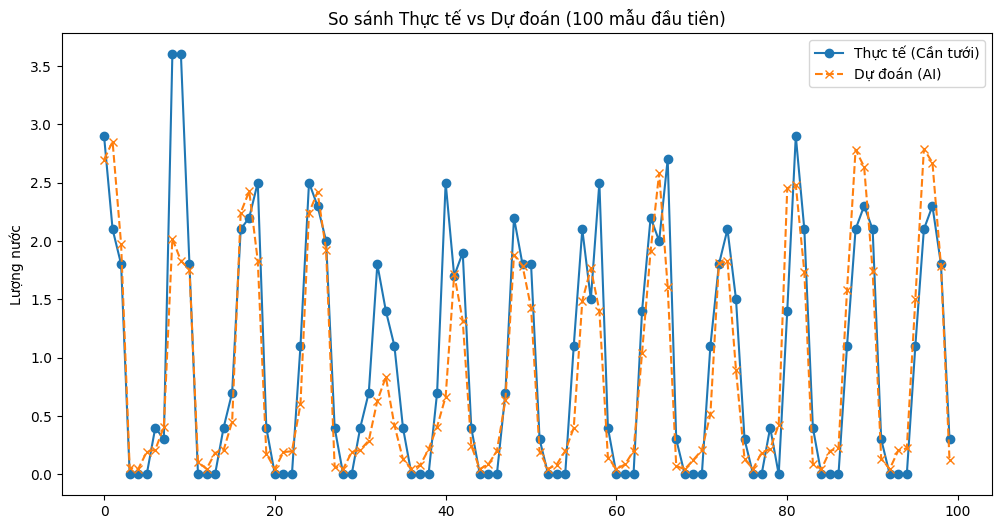

In [21]:
# Evaluate model

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, recall_score

print("\n--- Đánh giá mô hình trên tập Test (Tương lai) ---")

# 1. Dự đoán
y_pred = lgb_reg.predict(X_test)

# 2. Ép các giá trị âm về 0 (Mô hình hồi quy đôi khi dự đoán -0.01)
y_pred = np.maximum(y_pred, 0)

# 3. Metrics Hồi quy (Độ chính xác về lượng nước)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📉 RMSE (Sai số bình phương trung bình): {rmse:.4f}")
print(f"📉 MAE (Sai số tuyệt đối trung bình):  {mae:.4f}")
print(f"📊 R2 Score (Độ phù hợp): {r2:.4f}")

# 4. CHECK RECALL (Kiểm tra an toàn)
# Nếu thực tế cần > 0.1 đơn vị nước, mà model dự đoán > 0.1, thì là ĐÚNG.
threshold = 0.1 

y_test_binary = (y_test > threshold).astype(int)
y_pred_binary = (y_pred > threshold).astype(int)

recall = recall_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)

print(f"\n--- Kiểm tra an toàn (Classification Proxy) ---")
print(f"🛡️ RECALL (Độ nhạy - Quan trọng nhất): {recall:.4f}")
print(f"🎯 PRECISION (Độ chính xác khi tưới):  {precision:.4f}")

# 5. Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Thực tế (Cần tưới)', marker='o')
plt.plot(y_pred[:100], label='Dự đoán (AI)', linestyle='--', marker='x')
plt.title("So sánh Thực tế vs Dự đoán (100 mẫu đầu tiên)")
plt.ylabel("Lượng nước")
plt.legend()
plt.show()

